# 1. Problem Understanding
The goal is to predict whether a passenger survived the Titanic disaster based on:

* Gender

* Age

* Passenger class

* Fare and family information

This is a binary classification problem.

# 2. Dataset Description

From Kaggle Titanic dataset:

| Column   | Description |
|----------|------------|
| Survived | Target (0 = No, 1 = Yes) |
| Pclass   | Passenger class (1, 2, 3) |
| Sex      | Gender |
| Age      | Age |
| SibSp    | Siblings/Spouses aboard |
| Parch    | Parents/Children aboard |
| Fare     | Ticket fare |
| Embarked | Port of embarkation |


# 3. Load the Dataset

In [1]:
import pandas as pd

data = pd.read_csv(r"C:\Users\telug\Downloads\train.csv")
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Data Cleaning & Preparation
Handle Missing Values

In [2]:

data["Age"] = data["Age"].fillna(data["Age"].median())

data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])


# 5. Exploratory Data Analysis (EDA)

## Survival by Gender

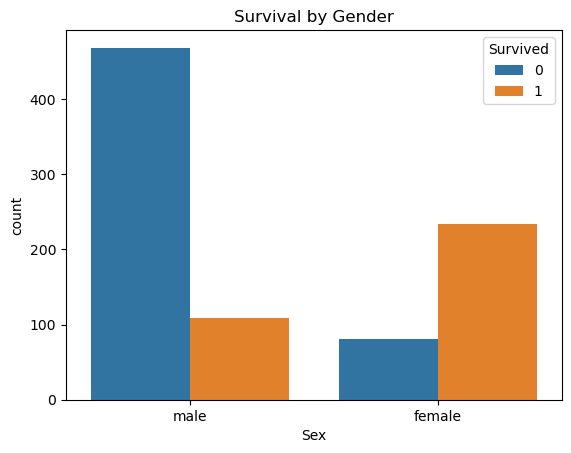

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sex", hue="Survived", data=data)
plt.title("Survival by Gender")
plt.show()


## Survival by Passenger Class

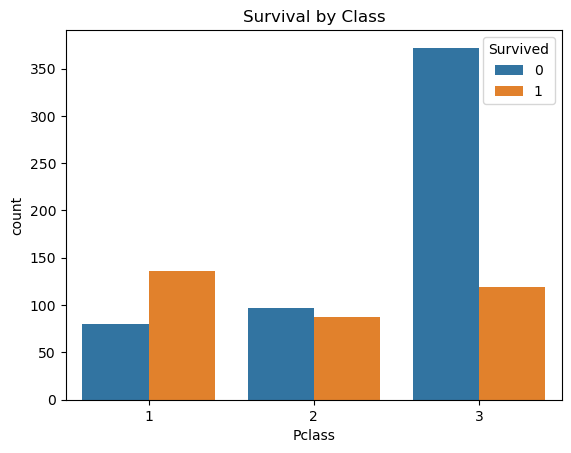

In [4]:
sns.countplot(x="Pclass", hue="Survived", data=data)
plt.title("Survival by Class")
plt.show()


## Survival by Age

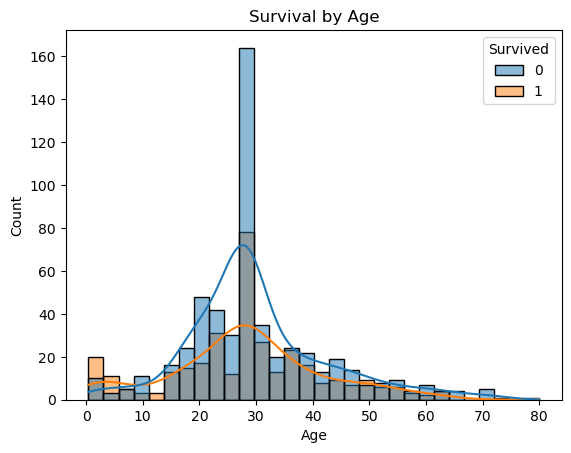

In [5]:
sns.histplot(data=data, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Survival by Age")
plt.show()


# Insights to write:

* Females survived more than males

* First-class passengers had higher survival rates

* Children had better survival chances

# 6. Encode Categorical Variables

In [6]:
data = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)


# 7. Feature Selection

In [7]:
X = data.drop("Survived", axis=1)

y = data["Survived"]


In [16]:
# Drop columns safely
X = X.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

# Handle missing values (only for columns that exist)
if 'Age' in X.columns:
    X['Age'] = X['Age'].fillna(X['Age'].median())
if 'Fare' in X.columns:
    X['Fare'] = X['Fare'].fillna(X['Fare'].median())
if 'Embarked' in X.columns:
    X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# Encode categorical columns (only if exist)
categorical_cols = []
for col in ['Sex', 'Embarked']:
    if col in X.columns:
        categorical_cols.append(col)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


# 8. Train–Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 9. Build Models

## 🔹 Scale the data + Logistic Regression

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


## 🔹 Decision Tree Classifier

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


# 10. Model Evaluation
Accuracy Score

In [20]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Logistic Regression Accuracy: 0.8044692737430168
Decision Tree Accuracy: 0.7206703910614525


## Confusion Matrix

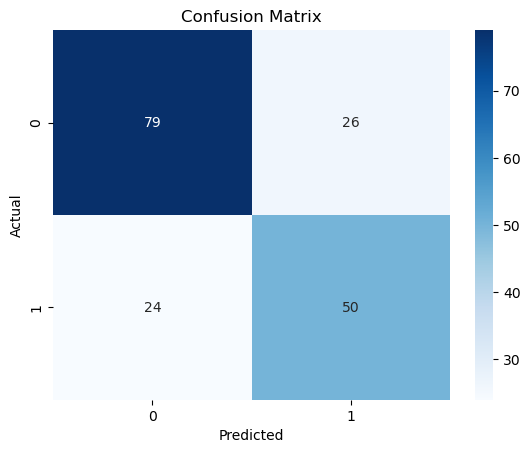

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 11. Conclusion (Write This in Your Project)

* Gender and passenger class strongly influence survival.

* Logistic Regression provides stable and interpretable results.

* Decision Trees capture complex patterns but may overfit.

* The model achieves good accuracy in predicting survival.

# 12. Optional Improvements

* Feature engineering (FamilySize = SibSp + Parch)

* Hyperparameter tuning

* Random Forest or XGBoost

* Cross-validation